### 4.1) Risk Metrics

This notebook computes mini-grid-relevant risk metrics for two scenarios:

- Scenario A: PV derived from actual irradiance
- Scenario B: PV derived from forecast irradiance

The objective is to quantify how forecast uncertainty changes:

- unserved energy
- loss-of-load hours
- curtailed energy
- battery throughput

The main output is the delta table:

**Forecast − Perfect**

### 4.2) Imports

In [42]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path

from src.config import SimConfig
from src.metrics import risk_metrics, risk_deltas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 4.3) Load Simulation Outputs

In [43]:
# Loads the final dispatch outputs and restores the time index.

sim = SimConfig()

A = pd.read_csv("../data/processed/sim_perfect.csv")
B = pd.read_csv("../data/processed/sim_forecast.csv")

A["time"] = pd.to_datetime(A["time"], utc=True)
B["time"] = pd.to_datetime(B["time"], utc=True)

A = A.set_index("time")
B = B.set_index("time")

print("Scenario A shape:", A.shape)
print("Scenario B shape:", B.shape)

A.head()

Scenario A shape: (8735, 9)
Scenario B shape: (8735, 9)


,pv_ac_kw,load_kw,served_load_kw,unserved_load_kw,curtailed_pv_kw,soc,charge_kw,discharge_kw,battery_throughput_kwh
time,,,,,,,,,
2025-01-01 00:00:00+00:00,NaN,20.182830,20.182830,0.000000,0.0,0.393775,0.0,20.182830,20.182830
2025-01-01 01:00:00+00:00,NaN,19.426256,19.426256,0.000000,0.0,0.291531,0.0,19.426256,19.426256
2025-01-01 02:00:00+00:00,NaN,20.758769,20.758769,0.000000,0.0,0.182274,0.0,20.758769,20.758769
2025-01-01 03:00:00+00:00,NaN,21.819825,15.632144,6.187681,0.0,0.100000,0.0,15.632144,15.632144
2025-01-01 04:00:00+00:00,NaN,22.388684,0.000000,22.388684,0.0,0.100000,0.0,0.000000,0.000000


### 4.4) Compute Metrics for each Scenario

In [44]:
metrics_A = risk_metrics(A, sim)
metrics_B = risk_metrics(B, sim)

print("Scenario A metrics:")
print(metrics_A)

print("\nScenario B metrics:")
print(metrics_B)

Scenario A metrics:
unserved_energy_kwh       197741.927044
lolh_hours                  5551.000000
curtailment_kwh            20430.125299
battery_throughput_kwh    107460.724647
dtype: float64

Scenario B metrics:
unserved_energy_kwh       188203.665827
lolh_hours                  5258.000000
curtailment_kwh            11761.945811
battery_throughput_kwh    110933.607840
dtype: float64


#### Interpretation

- **unserved_energy_kwh**: total energy not served

- **lolh_hours**: how many hours the system had unmet demand

- **curtailment_kwh**: how much PV could not be used

- **battery_throughput_kwh**: cycling stress proxy

### 4.5) Build a Delta Table and Save Output

In [45]:
# Buidling the delta table
table = risk_deltas(metrics_A, metrics_B)

# Saving the output
output_dir = Path("../reports/tables")
output_dir.mkdir(parents=True, exist_ok=True)

csv_path = output_dir / "risk_deltas.csv"
table.to_csv(csv_path)

print("Saved:", csv_path)
table

Saved: ..\reports\tables\risk_deltas.csv


,perfect,forecast,delta_B_minus_A
unserved_energy_kwh,197741.927044,188203.665827,-9538.261217
lolh_hours,5551.000000,5258.000000,-293.000000
curtailment_kwh,20430.125299,11761.945811,-8668.179487
battery_throughput_kwh,107460.724647,110933.607840,3472.883192


In [46]:
md_path = output_dir / "risk_deltas.md"

with open(md_path, "w", encoding="utf-8") as f:
    f.write(table.to_markdown())

print("Saved:", md_path)

Saved: ..\reports\tables\risk_deltas.md


### 4.6) Interpretation

The delta table quantifies the operational penalty introduced by forecast uncertainty.

The most important question is not whether forecast error exists, but how strongly it changes:

- energy not served
- the number of hours with supply shortfall
- wasted solar energy
- battery cycling stress

A positive delta in unserved energy or LOLH indicates that forecast error worsens reliability.

A negative delta in curtailment may indicate that reduced forecast-based PV generation lowers surplus energy, though this may come at the cost of reliability.

### 4.7) When Forecast Hurts Most

#### i) Hourly Comparison

In [51]:
compare = pd.DataFrame(index=A.index)
compare["unserved_perfect"] = A["unserved_load_kw"]
compare["unserved_forecast"] = B["unserved_load_kw"]
compare["delta_unserved_kw"] = compare["unserved_forecast"] - compare["unserved_perfect"]

compare.head(24)

,unserved_perfect,unserved_forecast,delta_unserved_kw
time,,,
2025-01-01 00:00:00+00:00,0.000000,0.000000,0.000000
2025-01-01 01:00:00+00:00,0.000000,0.000000,0.000000
2025-01-01 02:00:00+00:00,0.000000,0.000000,0.000000
2025-01-01 03:00:00+00:00,6.187681,6.187681,0.000000
2025-01-01 04:00:00+00:00,22.388684,22.388684,0.000000
2025-01-01 05:00:00+00:00,27.946188,27.946188,0.000000
2025-01-01 06:00:00+00:00,36.080390,16.348345,-19.732045
2025-01-01 07:00:00+00:00,25.606269,15.843286,-9.762984
2025-01-01 08:00:00+00:00,5.822099,0.000000,-5.822099


#### ii) Monthly Aggregation

In [48]:
monthly_delta = compare.groupby(compare.index.month)["delta_unserved_kw"].sum()
monthly_delta

time
1     -525.738224
2     -284.215579
3       23.418893
4     -468.455261
5     -533.675905
6    -1001.734303
7    -1735.407414
8    -2028.568022
9    -1358.026257
10    -758.720240
11    -327.958038
12    -539.180868
Name: delta_unserved_kw, dtype: float64

#### iii) Plot Monthly delta

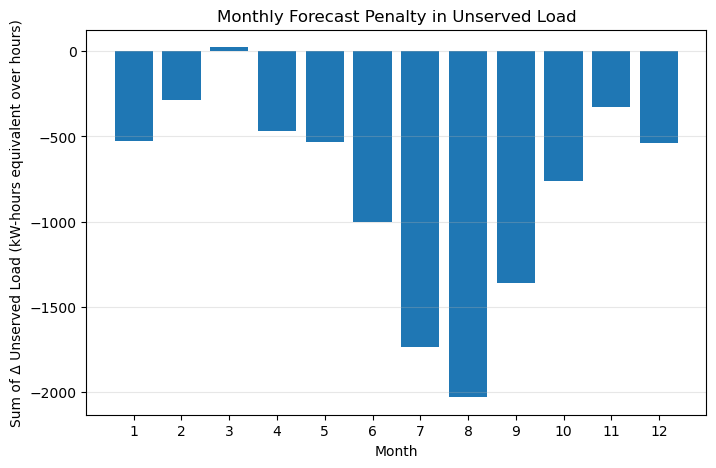

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(monthly_delta.index, monthly_delta.values)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Sum of Δ Unserved Load (kW-hours equivalent over hours)")
plt.title("Monthly Forecast Penalty in Unserved Load")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Key Observations

- Forecast-driven operation reduces unserved energy by ~9.5 MWh and LOLH by 293 hours.
- Curtailment decreases significantly (~8.7 MWh), indicating improved utilization of solar energy.
- Battery throughput increases, reflecting more active cycling under forecast variability.

### Interpretation

Despite imperfect accuracy, the forecast improves operational performance under rule-based dispatch. This occurs because forecast-induced variability leads to more responsive battery usage, reducing both curtailment and unmet demand.

### Seasonal Behavior

The largest improvements occur during high-variability months (July–September), confirming that forecast value increases under uncertain conditions.